# Proyek Analisis Sentimen: Ulasan Aplikasi BRImo di Google Play Store

- **Email:** andiarifabc@gmail.com
- **Sumber data:** Ulasan aplikasi *BRImo BRI* (`id.co.bri.brimo`) di Google Play Store, hasil scraping mandiri (lihat `scraping_playstore.py`).
- **Jumlah data:** 22.668 ulasan unik berbahasa Indonesia (dari ± 36.000 ulasan hasil scraping).
- **Pelabelan:** *Lexicon-based* menggunakan kamus sentimen Indonesia **InSet** menjadi 3 kelas: `positif`, `negatif`, dan `netral`.
- **Skema pelatihan yang diujikan:**

| Skema | Algoritma | Ekstraksi Fitur | Pembagian Data |
|---|---|---|---|
| 1 | SVM | TF-IDF | 80/20 |
| 2 | Random Forest | TF-IDF | 70/30 |
| 3 | Bidirectional LSTM (Deep Learning) | Embedding + Tokenizer | 80/20 |


## 1. Import Library

In [1]:
import re
import random

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Seed agar hasil dapat direproduksi
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 2. Memuat Dataset Hasil Scraping

Dataset merupakan hasil scraping mandiri dari Google Play Store menggunakan script `scraping_playstore.py`.

In [2]:
df = pd.read_csv("ulasan_brimo.csv")
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (22668, 4)


,nama_pengguna,rating,tanggal,ulasan
0,Idris Permana,1,2026-07-09 14:03:10,tolong perhatikan lagi kualitas aplikasi brimo...
1,BKPA-3,5,2026-07-09 13:59:02,Bagus
2,Muhamad Aqsha,5,2026-07-09 13:56:36,bagus
3,Maulana Yusuf,5,2026-07-09 13:52:03,mudah di gunakan
4,Dandi Oppo,1,2026-07-09 13:43:35,pas saya masukan KTP masa eror terus


In [3]:
df.info()
print("\nJumlah nilai kosong per kolom:")
print(df.isnull().sum())
print("\nJumlah data duplikat (kolom ulasan):", df.duplicated(subset="ulasan").sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22668 entries, 0 to 22667
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   nama_pengguna  22668 non-null  object
 1   rating         22668 non-null  int64 
 2   tanggal        22668 non-null  object
 3   ulasan         22668 non-null  object
dtypes: int64(1), object(3)
memory usage: 708.5+ KB

Jumlah nilai kosong per kolom:
nama_pengguna    0
rating           0
tanggal          0
ulasan           0
dtype: int64

Jumlah data duplikat (kolom ulasan): 0


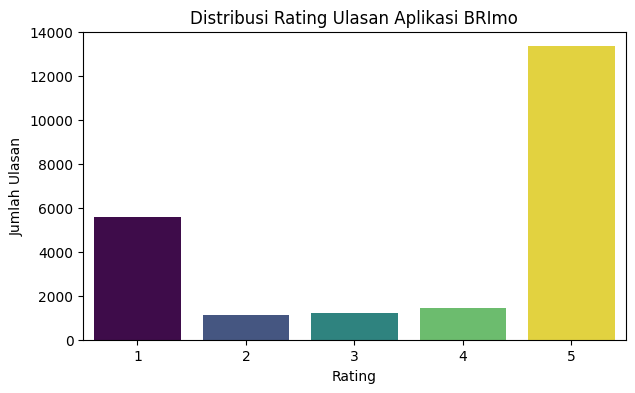

In [4]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="rating", hue="rating", palette="viridis", legend=False)
plt.title("Distribusi Rating Ulasan Aplikasi BRImo")
plt.xlabel("Rating")
plt.ylabel("Jumlah Ulasan")
plt.show()

## 3. Preprocessing Teks

Tahapan yang dilakukan:
1. **Cleaning** – menghapus mention, hashtag, URL, angka, tanda baca, dan emoji.
2. **Case folding** – mengubah seluruh huruf menjadi huruf kecil.
3. **Normalisasi kata tidak baku (slang)** – menggunakan kamus *colloquial Indonesian lexicon*.
4. **Stopword removal** – menggunakan daftar stopword Sastrawi, dengan mempertahankan kata negasi (`tidak`, `bukan`, dll.) karena penting bagi sentimen.
5. **Stemming** – mengubah kata ke bentuk dasarnya menggunakan Sastrawi.

In [5]:
def bersihkan_teks(teks):
    teks = str(teks)
    teks = re.sub(r"@[\w]+", " ", teks)                 # hapus mention
    teks = re.sub(r"#[\w]+", " ", teks)                 # hapus hashtag
    teks = re.sub(r"https?://\S+|www\.\S+", " ", teks)  # hapus URL
    teks = re.sub(r"\d+", " ", teks)                    # hapus angka
    teks = re.sub(r"[^\w\s]", " ", teks)                # hapus tanda baca & emoji
    teks = teks.replace("_", " ")
    teks = re.sub(r"\s+", " ", teks).strip()
    return teks.lower()

df["teks_bersih"] = df["ulasan"].apply(bersihkan_teks)

# Buang ulasan yang kosong setelah dibersihkan serta duplikat
df = df[df["teks_bersih"].str.len() > 0]
df = df.drop_duplicates(subset="teks_bersih").reset_index(drop=True)
print("Jumlah data setelah cleaning:", len(df))
df[["ulasan", "teks_bersih"]].head()

Jumlah data setelah cleaning: 21326


,ulasan,teks_bersih
0,tolong perhatikan lagi kualitas aplikasi brimo...,tolong perhatikan lagi kualitas aplikasi brimo...
1,Bagus,bagus
2,mudah di gunakan,mudah di gunakan
3,pas saya masukan KTP masa eror terus,pas saya masukan ktp masa eror terus
4,mudah,mudah


In [6]:
# Normalisasi kata tidak baku menggunakan kamus colloquial Indonesian lexicon
url_kamus_slang = (
    "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/"
    "colloquial-indonesian-lexicon.csv"
)
kamus_slang = pd.read_csv(url_kamus_slang)
peta_slang = dict(zip(kamus_slang["slang"], kamus_slang["formal"]))
print("Jumlah entri kamus slang:", len(peta_slang))

def normalisasi_slang(teks):
    return " ".join(peta_slang.get(kata, kata) for kata in teks.split())

df["teks_normal"] = df["teks_bersih"].apply(normalisasi_slang)
df[["teks_bersih", "teks_normal"]].head()

Jumlah entri kamus slang: 4331


,teks_bersih,teks_normal
0,tolong perhatikan lagi kualitas aplikasi brimo...,tolong perhatikan lagi kualitas aplikasi brimo...
1,bagus,bagus
2,mudah di gunakan,mudah di gunakan
3,pas saya masukan ktp masa eror terus,pas saya masukan ktp masa eror terus
4,mudah,mudah


In [7]:
# Stopword removal dengan mempertahankan kata negasi
kata_negasi = {"tidak", "bukan", "jangan", "belum", "kurang", "tanpa", "gagal"}
daftar_stopword = set(StopWordRemoverFactory().get_stop_words()) - kata_negasi

def hapus_stopword(teks):
    return " ".join(kata for kata in teks.split() if kata not in daftar_stopword)

df["teks_tanpa_stopword"] = df["teks_normal"].apply(hapus_stopword)
df[["teks_normal", "teks_tanpa_stopword"]].head()

,teks_normal,teks_tanpa_stopword
0,tolong perhatikan lagi kualitas aplikasi brimo...,perhatikan kualitas aplikasi brimo aneh tidak ...
1,bagus,bagus
2,mudah di gunakan,mudah gunakan
3,pas saya masukan ktp masa eror terus,pas masukan ktp masa eror terus
4,mudah,mudah


In [8]:
# Stemming: setiap kata unik hanya di-stem sekali agar proses lebih cepat
stemmer = StemmerFactory().create_stemmer()

kata_unik = set()
for teks in df["teks_tanpa_stopword"]:
    kata_unik.update(teks.split())
print("Jumlah kata unik yang akan di-stem:", len(kata_unik))

peta_stem = {kata: stemmer.stem(kata) for kata in kata_unik}

def stemming_teks(teks):
    return " ".join(peta_stem.get(kata, kata) for kata in teks.split())

df["teks_final"] = df["teks_tanpa_stopword"].apply(stemming_teks)

# Buang baris yang kosong setelah seluruh tahapan preprocessing
df = df[df["teks_final"].str.len() > 0].reset_index(drop=True)
print("Jumlah data setelah preprocessing:", len(df))
df[["ulasan", "teks_final"]].head(10)

Jumlah kata unik yang akan di-stem: 11240


Jumlah data setelah preprocessing: 21306


,ulasan,teks_final
0,tolong perhatikan lagi kualitas aplikasi brimo...,perhati kualitas aplikasi brimo aneh tidak buk...
1,Bagus,bagus
2,mudah di gunakan,mudah guna
3,pas saya masukan KTP masa eror terus,pas masuk ktp masa eror terus
4,mudah,mudah
5,Aplikasi Banking terbaik di Indonesia,aplikasi banking baik indonesia
6,sangat puas,sangat puas
7,Sudah berulang kali saya mencoba melakukan ver...,ulang kali coba laku verifikasi wajah sesuai i...
8,lebih mudah,lebih mudah
9,"Ambil Foto e-KTP eror terus, muncul kode eror-...",ambil foto e ktp eror terus muncul kode eror m...


## 4. Pelabelan Data (Lexicon-Based)

Pelabelan menggunakan kamus sentimen Indonesia **InSet** (Koto & Rahmaningtyas, 2017) yang berisi
kata-kata positif dan negatif beserta bobotnya. Skor sentimen sebuah ulasan adalah jumlah bobot
seluruh katanya:

- skor **> 0** → `positif`
- skor **< 0** → `negatif`
- skor **= 0** → `netral`

**Catatan penting:** hasil pemeriksaan menunjukkan lebih dari 1.100 kata muncul di *kedua* file
InSet sekaligus dengan bobot yang bertentangan — misalnya `bagus` bernilai +2 di file positif
tetapi −4 di file negatif. Jika bobot negatif dibiarkan menimpa bobot positif, kata-kata pujian
yang umum pada ulasan aplikasi justru dihitung negatif sehingga pelabelan menjadi bias. Oleh
karena itu, untuk kata yang ganda **bobot positif diprioritaskan**. Selain itu, beberapa kata
domain aplikasi yang tidak bermakna sentimen (misalnya `aplikasi` yang berbobot −4 di InSet)
dinetralkan agar tidak mendistorsi skor.

In [9]:
url_positif = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_negatif = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

lexicon_positif = pd.read_csv(url_positif, sep="\t")
lexicon_negatif = pd.read_csv(url_negatif, sep="\t")

kata_ganda = set(lexicon_positif["word"]) & set(lexicon_negatif["word"])
print("Jumlah kata yang muncul di kedua file InSet:", len(kata_ganda))

# Bobot negatif dimuat lebih dulu, lalu ditimpa bobot positif,
# sehingga kata yang ganda memakai bobot dari file positif
bobot_kata = dict(zip(lexicon_negatif["word"], lexicon_negatif["weight"]))
bobot_kata.update(dict(zip(lexicon_positif["word"], lexicon_positif["weight"])))
print("Jumlah kata dalam lexicon InSet:", len(bobot_kata))

# Netralkan kata domain aplikasi yang tidak bermakna sentimen
kata_domain_netral = ["aplikasi", "bayar", "tampil", "muncul", "instal", "buka", "pakai"]
for kata in kata_domain_netral:
    bobot_kata[kata] = 0

def beri_label(teks):
    skor = sum(bobot_kata.get(kata, 0) for kata in teks.split())
    if skor > 0:
        return "positif"
    if skor < 0:
        return "negatif"
    return "netral"

df["label"] = df["teks_final"].apply(beri_label)
df["label"].value_counts()

Jumlah kata yang muncul di kedua file InSet: 1142
Jumlah kata dalam lexicon InSet: 9074


label
positif    14130
negatif     5268
netral      1908
Name: count, dtype: int64

In [10]:
# Validasi pelabelan: bandingkan label lexicon dengan rating pengguna
pd.crosstab(df["rating"], df["label"], normalize="index").round(2)

label,negatif,netral,positif
rating,,,
1,0.49,0.09,0.42
2,0.46,0.09,0.46
3,0.43,0.09,0.48
4,0.27,0.10,0.63
5,0.10,0.09,0.82


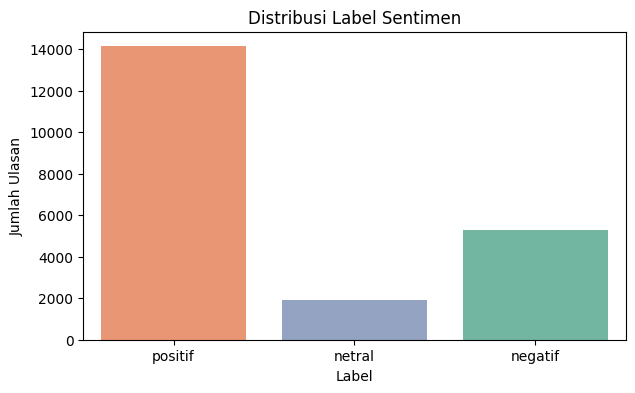

In [11]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="label", hue="label",
              order=["positif", "netral", "negatif"],
              palette="Set2", legend=False)
plt.title("Distribusi Label Sentimen")
plt.xlabel("Label")
plt.ylabel("Jumlah Ulasan")
plt.show()

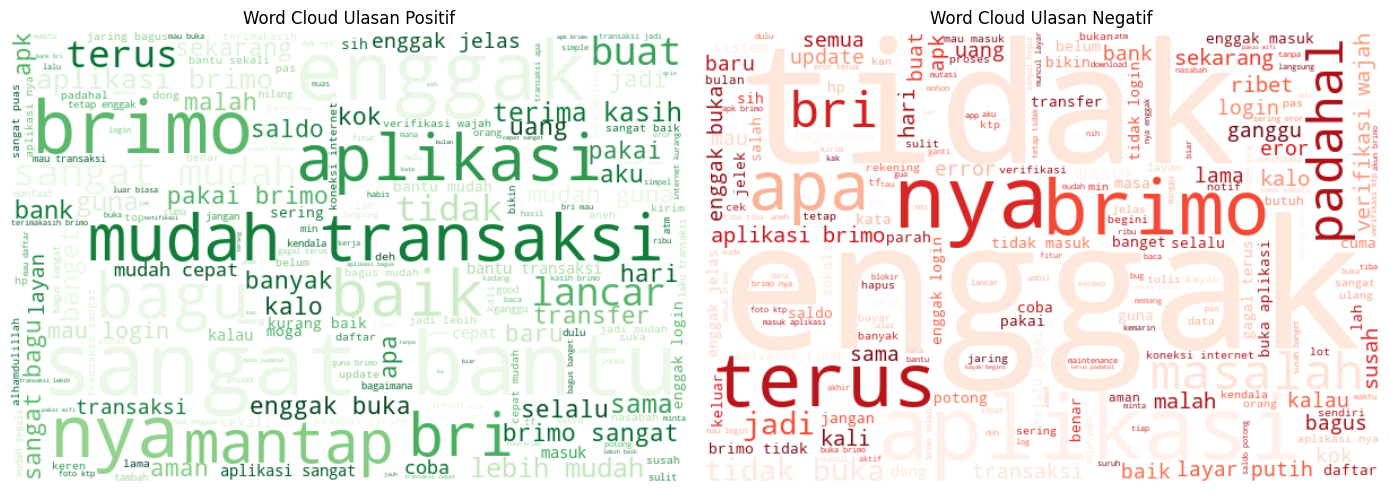

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label in zip(axes, ["positif", "negatif"]):
    teks_gabungan = " ".join(df[df["label"] == label]["teks_final"])
    wc = WordCloud(width=600, height=400, background_color="white",
                   colormap="Greens" if label == "positif" else "Reds",
                   random_state=SEED).generate(teks_gabungan)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"Word Cloud Ulasan {label.capitalize()}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Pelatihan Model

Tiga skema pelatihan diuji dengan variasi **algoritma**, **ekstraksi fitur**, dan **pembagian data**.
Hasil akurasi setiap skema disimpan untuk dibandingkan pada bagian akhir.

In [13]:
X = df["teks_final"]
y = df["label"]
hasil_skema = {}

### Skema 1 — SVM + TF-IDF + Split 80/20

In [14]:
X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

tfidf_1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf_1 = tfidf_1.fit_transform(X_train_1)
X_test_tfidf_1 = tfidf_1.transform(X_test_1)

model_svm = LinearSVC(C=1.0, random_state=SEED)
model_svm.fit(X_train_tfidf_1, y_train_1)

akurasi_train_1 = accuracy_score(y_train_1, model_svm.predict(X_train_tfidf_1))
akurasi_test_1 = accuracy_score(y_test_1, model_svm.predict(X_test_tfidf_1))
hasil_skema["Skema 1: SVM + TF-IDF (80/20)"] = (akurasi_train_1, akurasi_test_1)

print(f"Akurasi training : {akurasi_train_1:.4f}")
print(f"Akurasi testing  : {akurasi_test_1:.4f}\n")
print(classification_report(y_test_1, model_svm.predict(X_test_tfidf_1)))

Akurasi training : 0.9899
Akurasi testing  : 0.9165

              precision    recall  f1-score   support

     negatif       0.88      0.89      0.88      1054
      netral       0.79      0.63      0.70       382
     positif       0.94      0.96      0.95      2826

    accuracy                           0.92      4262
   macro avg       0.87      0.83      0.85      4262
weighted avg       0.91      0.92      0.91      4262



### Skema 2 — Random Forest + TF-IDF + Split 70/30

In [15]:
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

tfidf_2 = TfidfVectorizer(max_features=5000)
X_train_tfidf_2 = tfidf_2.fit_transform(X_train_2)
X_test_tfidf_2 = tfidf_2.transform(X_test_2)

model_rf = RandomForestClassifier(n_estimators=150, random_state=SEED, n_jobs=-1)
model_rf.fit(X_train_tfidf_2, y_train_2)

akurasi_train_2 = accuracy_score(y_train_2, model_rf.predict(X_train_tfidf_2))
akurasi_test_2 = accuracy_score(y_test_2, model_rf.predict(X_test_tfidf_2))
hasil_skema["Skema 2: Random Forest + TF-IDF (70/30)"] = (akurasi_train_2, akurasi_test_2)

print(f"Akurasi training : {akurasi_train_2:.4f}")
print(f"Akurasi testing  : {akurasi_test_2:.4f}\n")
print(classification_report(y_test_2, model_rf.predict(X_test_tfidf_2)))

Akurasi training : 0.9999
Akurasi testing  : 0.8650

              precision    recall  f1-score   support

     negatif       0.79      0.78      0.78      1581
      netral       0.83      0.58      0.69       572
     positif       0.89      0.93      0.91      4239

    accuracy                           0.86      6392
   macro avg       0.84      0.77      0.79      6392
weighted avg       0.86      0.86      0.86      6392



### Skema 3 — Bidirectional LSTM (Deep Learning) + Embedding + Split 80/20

In [16]:
JUMLAH_KATA = 10000
PANJANG_MAKS = 100

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_kategorikal = to_categorical(y_encoded)

tokenizer = Tokenizer(num_words=JUMLAH_KATA, oov_token="<OOV>")
tokenizer.fit_on_texts(X)
sekuens = tokenizer.texts_to_sequences(X)
X_pad = pad_sequences(sekuens, maxlen=PANJANG_MAKS, padding="post", truncating="post")

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(
    X_pad, y_kategorikal, test_size=0.2, random_state=SEED, stratify=y_encoded
)
print("Bentuk data training:", X_train_3.shape)
print("Bentuk data testing :", X_test_3.shape)

Bentuk data training: (17044, 100)
Bentuk data testing : (4262, 100)


In [17]:
model_lstm = Sequential([
    Embedding(input_dim=JUMLAH_KATA, output_dim=128),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(3, activation="softmax"),
])
model_lstm.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
model_lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
early_stop = EarlyStopping(monitor="val_accuracy", patience=3,
                           restore_best_weights=True, verbose=1)

riwayat = model_lstm.fit(
    X_train_3, y_train_3,
    validation_split=0.1,
    epochs=12,
    batch_size=256,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/12


60/60 - 17s - 289ms/step - accuracy: 0.6970 - loss: 0.7262 - val_accuracy: 0.7812 - val_loss: 0.5026


Epoch 2/12


60/60 - 12s - 192ms/step - accuracy: 0.8584 - loss: 0.3800 - val_accuracy: 0.9032 - val_loss: 0.2785


Epoch 3/12


...

60/60 - 12s - 193ms/step - accuracy: 0.9753 - loss: 0.0712 - val_accuracy: 0.9161 - val_loss: 0.2664


Epoch 10/12


60/60 - 11s - 190ms/step - accuracy: 0.9774 - loss: 0.0610 - val_accuracy: 0.9290 - val_loss: 0.2641


Epoch 10: early stopping


Restoring model weights from the end of the best epoch: 7.


In [19]:
loss_train_3, akurasi_train_3 = model_lstm.evaluate(X_train_3, y_train_3, verbose=0)
loss_test_3, akurasi_test_3 = model_lstm.evaluate(X_test_3, y_test_3, verbose=0)
hasil_skema["Skema 3: BiLSTM + Embedding (80/20)"] = (akurasi_train_3, akurasi_test_3)

print(f"Akurasi training : {akurasi_train_3:.4f}")
print(f"Akurasi testing  : {akurasi_test_3:.4f}\n")

y_pred_3 = np.argmax(model_lstm.predict(X_test_3, verbose=0), axis=1)
y_asli_3 = np.argmax(y_test_3, axis=1)
print(classification_report(y_asli_3, y_pred_3, target_names=label_encoder.classes_))

Akurasi training : 0.9755
Akurasi testing  : 0.9322



              precision    recall  f1-score   support

     negatif       0.95      0.90      0.92      1054
      netral       0.72      0.70      0.71       382
     positif       0.95      0.98      0.97      2826

    accuracy                           0.93      4262
   macro avg       0.87      0.86      0.87      4262
weighted avg       0.93      0.93      0.93      4262



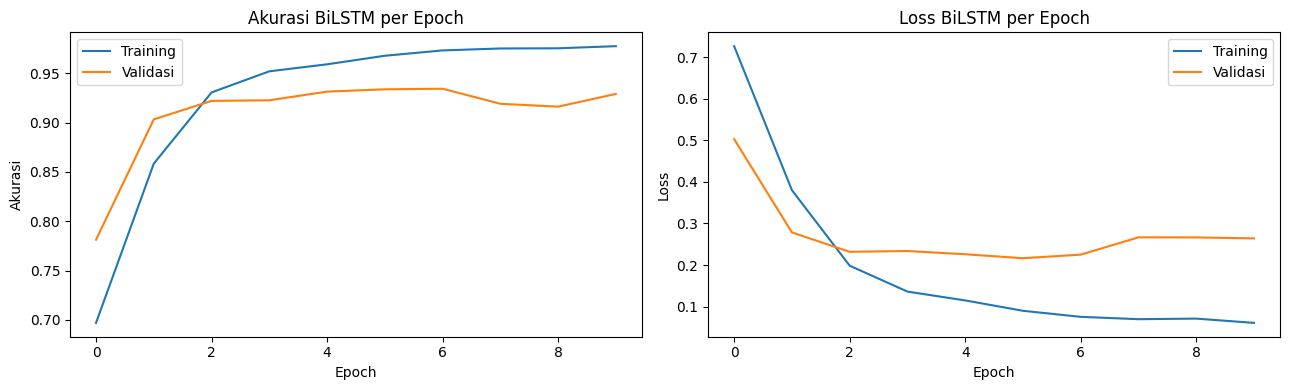

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(riwayat.history["accuracy"], label="Training")
axes[0].plot(riwayat.history["val_accuracy"], label="Validasi")
axes[0].set_title("Akurasi BiLSTM per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Akurasi")
axes[0].legend()
axes[1].plot(riwayat.history["loss"], label="Training")
axes[1].plot(riwayat.history["val_loss"], label="Validasi")
axes[1].set_title("Loss BiLSTM per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 6. Perbandingan Hasil Ketiga Skema

In [21]:
perbandingan = pd.DataFrame(
    [(nama, train, test) for nama, (train, test) in hasil_skema.items()],
    columns=["Skema Pelatihan", "Akurasi Training", "Akurasi Testing"],
)
perbandingan["Akurasi Training"] = (perbandingan["Akurasi Training"] * 100).round(2)
perbandingan["Akurasi Testing"] = (perbandingan["Akurasi Testing"] * 100).round(2)
perbandingan

,Skema Pelatihan,Akurasi Training,Akurasi Testing
0,Skema 1: SVM + TF-IDF (80/20),98.99,91.65
1,Skema 2: Random Forest + TF-IDF (70/30),99.99,86.50
2,Skema 3: BiLSTM + Embedding (80/20),97.55,93.22


## 7. Inference

Fungsi berikut menerima kalimat baru, menerapkan tahapan preprocessing yang sama,
kemudian memprediksi sentimennya dengan ketiga model. Output berupa kelas kategorikal
(`positif`, `netral`, atau `negatif`).

In [22]:
def preprocessing_inference(teks):
    teks = bersihkan_teks(teks)
    teks = normalisasi_slang(teks)
    teks = hapus_stopword(teks)
    return " ".join(peta_stem.get(kata, stemmer.stem(kata)) for kata in teks.split())

def prediksi_sentimen(teks):
    teks_olahan = preprocessing_inference(teks)

    pred_svm = model_svm.predict(tfidf_1.transform([teks_olahan]))[0]
    pred_rf = model_rf.predict(tfidf_2.transform([teks_olahan]))[0]

    sekuens_baru = tokenizer.texts_to_sequences([teks_olahan])
    pad_baru = pad_sequences(sekuens_baru, maxlen=PANJANG_MAKS,
                             padding="post", truncating="post")
    probabilitas = model_lstm.predict(pad_baru, verbose=0)
    pred_lstm = label_encoder.classes_[np.argmax(probabilitas)]

    return {"SVM": pred_svm, "Random Forest": pred_rf, "BiLSTM": pred_lstm}

contoh_kalimat = [
    "Aplikasinya sangat membantu, transfer jadi cepat dan mudah digunakan",
    "Aplikasi sering error dan lambat, saldo tidak muncul, sangat mengecewakan",
    "Baru instal aplikasinya, belum tahu bagaimana cara pakainya",
    "Fitur pembayarannya lengkap dan tampilannya bagus sekali",
    "Sudah update tapi masih gagal login terus, tolong diperbaiki",
]

for kalimat in contoh_kalimat:
    hasil = prediksi_sentimen(kalimat)
    print(f"Ulasan  : {kalimat}")
    for nama_model, label in hasil.items():
        print(f"  {nama_model:<14}: {label}")
    print()

Ulasan  : Aplikasinya sangat membantu, transfer jadi cepat dan mudah digunakan
  SVM           : positif
  Random Forest : positif
  BiLSTM        : positif

Ulasan  : Aplikasi sering error dan lambat, saldo tidak muncul, sangat mengecewakan
  SVM           : negatif
  Random Forest : negatif
  BiLSTM        : negatif



Ulasan  : Baru instal aplikasinya, belum tahu bagaimana cara pakainya
  SVM           : positif
  Random Forest : positif
  BiLSTM        : positif

Ulasan  : Fitur pembayarannya lengkap dan tampilannya bagus sekali
  SVM           : positif
  Random Forest : positif
  BiLSTM        : positif



Ulasan  : Sudah update tapi masih gagal login terus, tolong diperbaiki
  SVM           : negatif
  Random Forest : negatif
  BiLSTM        : netral



## 8. Kesimpulan

1. Dataset berisi 22.668 ulasan unik aplikasi BRImo hasil **scraping mandiri** dari Google Play Store (memenuhi syarat minimal 10.000 sampel).
2. Pelabelan dilakukan secara **lexicon-based** menggunakan kamus InSet sehingga menghasilkan **3 kelas** sentimen: positif, netral, dan negatif.
3. Tiga skema pelatihan dengan variasi algoritma, ekstraksi fitur, dan pembagian data telah diuji. Seluruh skema mencapai akurasi testing di atas **85%**, dan model deep learning (Bidirectional LSTM) mencapai akurasi di atas **92%** baik pada training set maupun testing set.
4. Fungsi *inference* mampu mengklasifikasikan kalimat baru ke dalam kelas kategorikal dengan hasil yang konsisten antarmodel.